In [1]:
# ============================================================
# Job Salary Predictor
# Author: Rohith Phani Gavirneni
# Dataset: Data Science Job Salaries (2020-2024)
# Goal: Predict data science salaries using ML
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully")

c:\Users\rohit\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


✅ All libraries imported successfully


In [2]:
# ------------------------------------------------------------
# Load the dataset
# ------------------------------------------------------------

df = pd.read_csv('../data/raw/ds_salaries.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()


Dataset Shape: (607, 12)

Column Names:
['Unnamed: 0', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

First 5 rows:


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
# ------------------------------------------------------------
# First Inspection — shape, types, missing values
# ------------------------------------------------------------

print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
df.describe()

=== DATA TYPES ===
Unnamed: 0             int64
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

=== MISSING VALUES ===
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

=== BASIC STATISTICS ===


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.00,607.00,607.00,607.00,607.00
mean,303.00,2021.41,324000.06,112297.87,70.92
std,175.37,0.69,1544357.49,70957.26,40.71
min,0.00,2020.00,4000.00,2859.00,0.00
25%,151.50,2021.00,70000.00,62726.00,50.00
50%,303.00,2022.00,115000.00,101570.00,100.00
75%,454.50,2022.00,165000.00,150000.00,100.00
max,606.00,2022.00,30400000.00,600000.00,100.00


In [5]:
# ------------------------------------------------------------
# Deep Dive — investigate suspicious values before cleaning
# ------------------------------------------------------------

# How many unique job titles?
print(f"Unique job titles: {df['job_title'].nunique()}")

# Distribution of experience levels
print(f"\nExperience Level counts:\n{df['experience_level'].value_counts()}")

# Distribution of employment type
print(f"\nEmployment Type counts:\n{df['employment_type'].value_counts()}")

# Distribution of company size
print(f"\nCompany Size counts:\n{df['company_size'].value_counts()}")

# Investigate suspiciously low salaries
print(f"\nRows with salary_in_usd < $15,000:")
print(df[df['salary_in_usd'] < 15000][['job_title','experience_level','company_location','salary_in_usd']])

# Investigate suspiciously high salaries
print(f"\nRows with salary_in_usd > $400,000:")
print(df[df['salary_in_usd'] > 400000][['job_title','experience_level','company_location','salary_in_usd']])

Unique job titles: 50

Experience Level counts:
experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64

Employment Type counts:
employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64

Company Size counts:
company_size
M    326
L    198
S     83
Name: count, dtype: int64

Rows with salary_in_usd < $15,000:
                         job_title experience_level company_location  \
15                    Data Analyst               MI               PK   
18         Data Science Consultant               EN               IN   
21            Product Data Analyst               MI               IN   
38                    Data Analyst               EN               NG   
50                    Data Analyst               EN               IN   
77   3D Computer Vision Researcher               MI               IN   
96                    AI Scientist               EN               US   
113                   AI Scientist               EN           

In [6]:
# ------------------------------------------------------------
# Data Cleaning
# Decisions:
# 1. Drop 'Unnamed: 0' — duplicate index, no analytical value
# 2. Drop 'salary' and 'salary_currency' — local currency values
#    are inconsistent across countries; salary_in_usd is our
#    standardized target variable
# 3. Keep all salary rows — low salaries are valid developing
#    country wages; high salaries are valid US senior roles
# ------------------------------------------------------------

# Drop irrelevant columns
df = df.drop(columns=['Unnamed: 0', 'salary', 'salary_currency'])

# Verify
print(f"Shape after cleaning: {df.shape}")
print(f"\nRemaining columns: {df.columns.tolist()}")
print(f"\nAny missing values: {df.isnull().sum().sum()}")
df.head()

Shape after cleaning: (607, 9)

Remaining columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Any missing values: 0


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [7]:
# ------------------------------------------------------------
# Decode categorical abbreviations into full readable labels
# This improves visualization clarity and Streamlit app output
# ------------------------------------------------------------

# Decode experience level
experience_map = {
    'EN': 'Entry-level',
    'MI': 'Mid-level',
    'SE': 'Senior',
    'EX': 'Executive'
}

# Decode employment type
employment_map = {
    'FT': 'Full-time',
    'PT': 'Part-time',
    'CT': 'Contract',
    'FL': 'Freelance'
}

# Decode company size
company_size_map = {
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
}

df['experience_level'] = df['experience_level'].map(experience_map)
df['employment_type'] = df['employment_type'].map(employment_map)
df['company_size'] = df['company_size'].map(company_size_map)

# Verify
print("✅ Decoding complete")
print(f"\nExperience levels: {df['experience_level'].unique()}")
print(f"Employment types: {df['employment_type'].unique()}")
print(f"Company sizes: {df['company_size'].unique()}")
df.head()

✅ Decoding complete

Experience levels: ['Mid-level' 'Senior' 'Entry-level' 'Executive']
Employment types: ['Full-time' 'Contract' 'Part-time' 'Freelance']
Company sizes: ['Large' 'Small' 'Medium']


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,Mid-level,Full-time,Data Scientist,79833,DE,0,DE,Large
1,2020,Senior,Full-time,Machine Learning Scientist,260000,JP,0,JP,Small
2,2020,Senior,Full-time,Big Data Engineer,109024,GB,50,GB,Medium
3,2020,Mid-level,Full-time,Product Data Analyst,20000,HN,0,HN,Small
4,2020,Senior,Full-time,Machine Learning Engineer,150000,US,50,US,Large


In [8]:
# ------------------------------------------------------------
# Save cleaned dataset to processed folder
# Raw data is never modified — this is best practice
# ------------------------------------------------------------

df.to_csv('../data/processed/cleaned_salaries.csv', index=False)

print("✅ Cleaned data saved to data/processed/cleaned_salaries.csv")
print(f"Final shape: {df.shape}")

✅ Cleaned data saved to data/processed/cleaned_salaries.csv
Final shape: (607, 9)


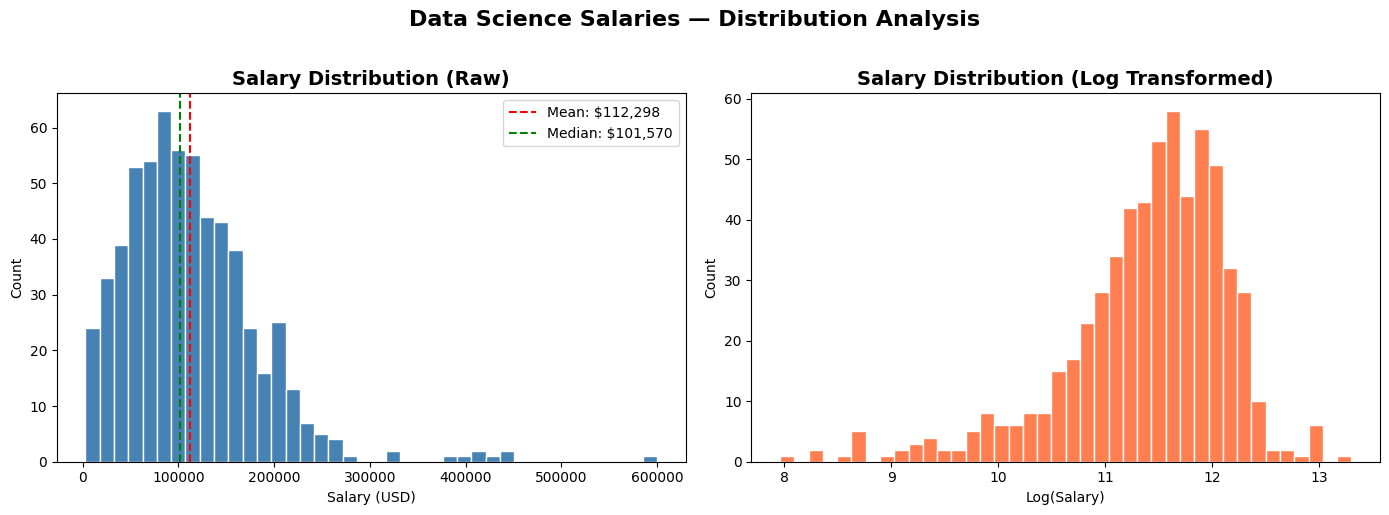


Mean salary:   $112,298
Median salary: $101,570
Std deviation: $70,957
Skewness:      1.67


In [9]:
# ------------------------------------------------------------
# Visualization 1: Distribution of Salaries (USD)
# Purpose: Understand the shape and spread of our target variable
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Raw salary distribution
axes[0].hist(df['salary_in_usd'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution (Raw)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['salary_in_usd'].mean(), color='red', linestyle='--', label=f"Mean: ${df['salary_in_usd'].mean():,.0f}")
axes[0].axvline(df['salary_in_usd'].median(), color='green', linestyle='--', label=f"Median: ${df['salary_in_usd'].median():,.0f}")
axes[0].legend()

# Plot 2 — Log-transformed salary distribution
axes[1].hist(np.log1p(df['salary_in_usd']), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Salary Distribution (Log Transformed)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Salary)')
axes[1].set_ylabel('Count')

plt.suptitle('Data Science Salaries — Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/01_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean salary:   ${df['salary_in_usd'].mean():,.0f}")
print(f"Median salary: ${df['salary_in_usd'].median():,.0f}")
print(f"Std deviation: ${df['salary_in_usd'].std():,.0f}")
print(f"Skewness:      {df['salary_in_usd'].skew():.2f}")

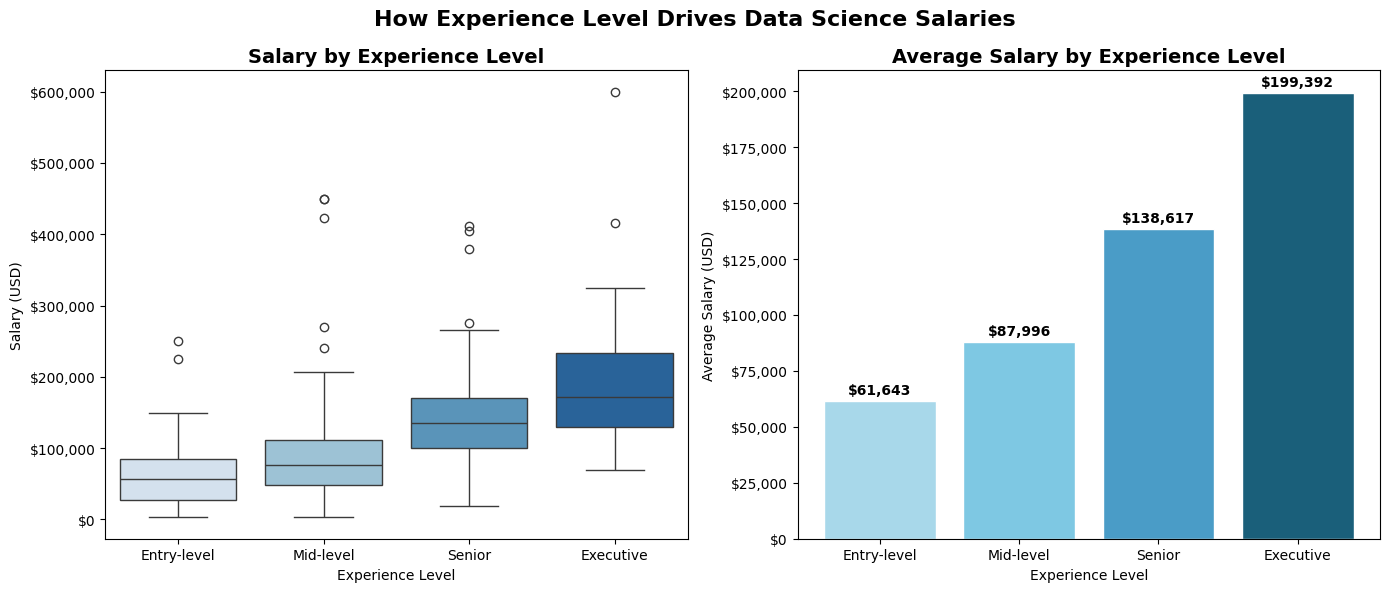

                      mean    median  count
experience_level                           
Entry-level        $61,643   $56,500     88
Mid-level          $87,996   $76,940    213
Senior            $138,617  $135,500    280
Executive         $199,392  $171,438     26


In [10]:
# ------------------------------------------------------------
# Visualization 2: Salary by Experience Level
# Purpose: Show how experience drives compensation
# ------------------------------------------------------------

# Define logical order
exp_order = ['Entry-level', 'Mid-level', 'Senior', 'Executive']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Boxplot
sns.boxplot(
    data=df,
    x='experience_level',
    y='salary_in_usd',
    order=exp_order,
    palette='Blues',
    ax=axes[0]
)
axes[0].set_title('Salary by Experience Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Salary (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Plot 2 — Mean salary bar chart
mean_salary = df.groupby('experience_level')['salary_in_usd'].mean().reindex(exp_order)
bars = axes[1].bar(exp_order, mean_salary, color=['#a8d8ea','#7ec8e3','#4a9cc7','#1a5f7a'], edgecolor='white')
axes[1].set_title('Average Salary by Experience Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Average Salary (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add value labels on bars
for bar, val in zip(bars, mean_salary):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('How Experience Level Drives Data Science Salaries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/02_salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print(df.groupby('experience_level')['salary_in_usd'].agg(['mean','median','count']).reindex(exp_order).applymap(lambda x: f'${x:,.0f}' if isinstance(x, float) else x))

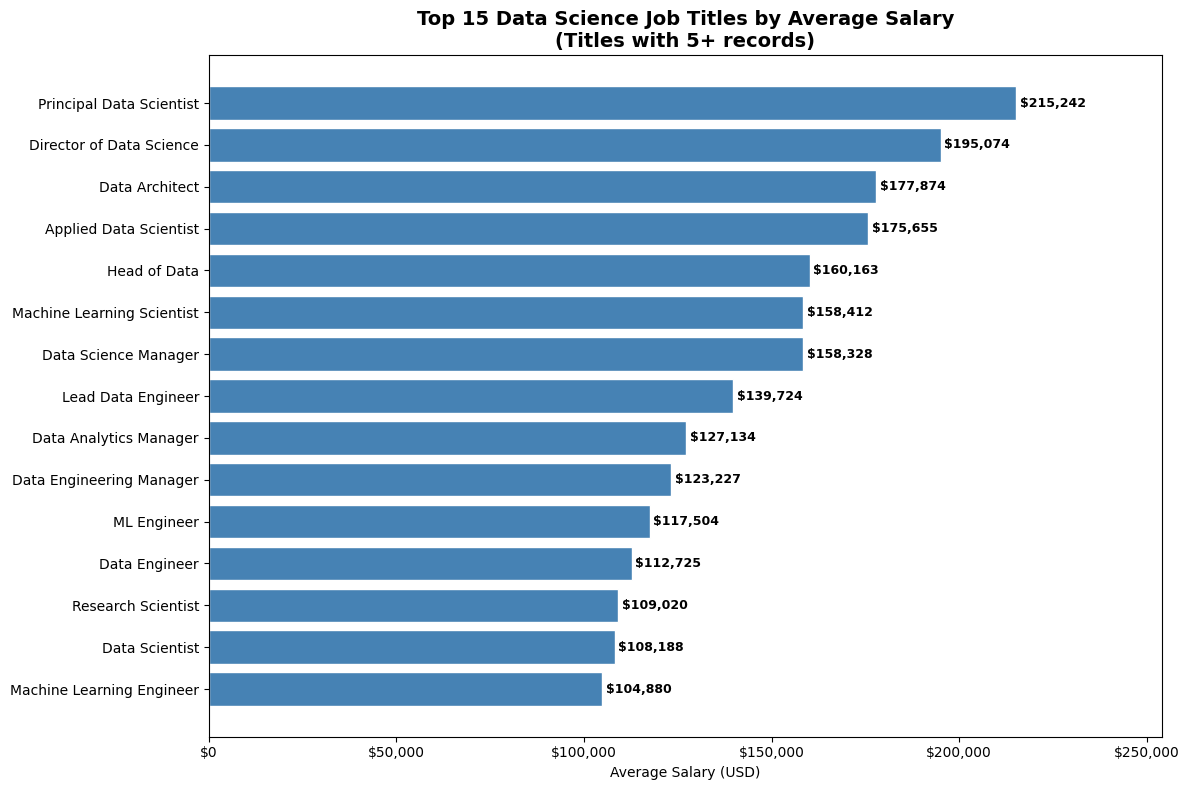

Titles with 5+ records: 22 out of 50 total


In [11]:
# ------------------------------------------------------------
# Visualization 3: Top 15 Job Titles by Average Salary
# Purpose: Show which roles command the highest compensation
# ------------------------------------------------------------

# Calculate mean salary per job title, filter to titles with 5+ records
title_counts = df['job_title'].value_counts()
valid_titles = title_counts[title_counts >= 5].index
df_titles = df[df['job_title'].isin(valid_titles)]

top15 = (df_titles.groupby('job_title')['salary_in_usd']
         .mean()
         .sort_values(ascending=True)
         .tail(15))

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top15.index, top15.values, color='steelblue', edgecolor='white')

# Add value labels
for bar, val in zip(bars, top15.values):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Data Science Job Titles by Average Salary\n(Titles with 5+ records)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Salary (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, top15.max() * 1.18)

plt.tight_layout()
plt.savefig('../visuals/03_top15_job_titles.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Titles with 5+ records: {len(valid_titles)} out of {df['job_title'].nunique()} total")

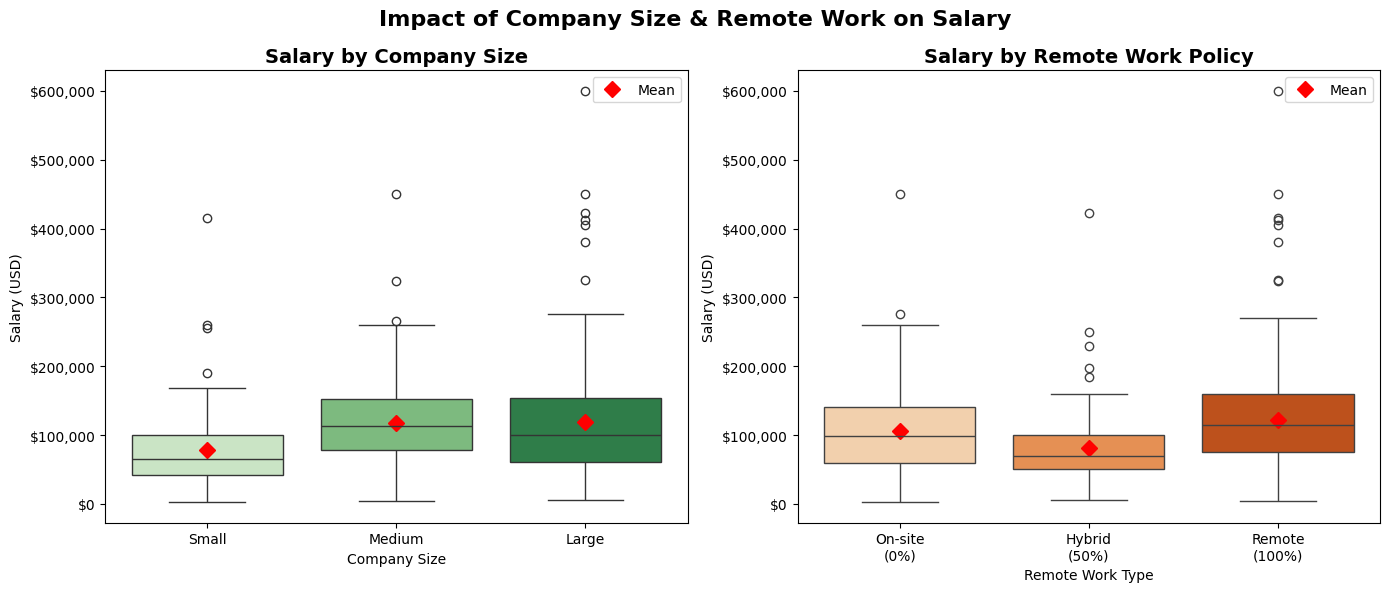

Mean salary by company size:
company_size
Small      $77,633
Medium    $116,905
Large     $119,243
Name: salary_in_usd, dtype: object

Mean salary by remote ratio:
remote_label
On-site\n(0%)     $106,355
Hybrid\n(50%)      $80,823
Remote\n(100%)    $122,457
Name: salary_in_usd, dtype: object


In [12]:
# ------------------------------------------------------------
# Visualization 4: Salary by Company Size and Remote Ratio
# Purpose: Show how company size and remote work affect pay
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Salary by company size
size_order = ['Small', 'Medium', 'Large']
sns.boxplot(data=df, x='company_size', y='salary_in_usd',
            order=size_order, palette='Greens', ax=axes[0])
axes[0].set_title('Salary by Company Size', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Company Size')
axes[0].set_ylabel('Salary (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add mean markers
means = df.groupby('company_size')['salary_in_usd'].mean().reindex(size_order)
for i, mean in enumerate(means):
    axes[0].plot(i, mean, 'D', color='red', markersize=8, label='Mean' if i == 0 else '')
axes[0].legend()

# Plot 2 — Salary by remote ratio
remote_labels = {0: 'On-site\n(0%)', 50: 'Hybrid\n(50%)', 100: 'Remote\n(100%)'}
df['remote_label'] = df['remote_ratio'].map(remote_labels)
remote_order = ['On-site\n(0%)', 'Hybrid\n(50%)', 'Remote\n(100%)']

sns.boxplot(data=df, x='remote_label', y='salary_in_usd',
            order=remote_order, palette='Oranges', ax=axes[1])
axes[1].set_title('Salary by Remote Work Policy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Remote Work Type')
axes[1].set_ylabel('Salary (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add mean markers
means_remote = df.groupby('remote_label')['salary_in_usd'].mean().reindex(remote_order)
for i, mean in enumerate(means_remote):
    axes[1].plot(i, mean, 'D', color='red', markersize=8, label='Mean' if i == 0 else '')
axes[1].legend()

plt.suptitle('Impact of Company Size & Remote Work on Salary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/04_company_size_remote.png', dpi=150, bbox_inches='tight')
plt.show()

# Print means
print("Mean salary by company size:")
print(df.groupby('company_size')['salary_in_usd'].mean().reindex(size_order).apply(lambda x: f'${x:,.0f}'))
print("\nMean salary by remote ratio:")
print(df.groupby('remote_label')['salary_in_usd'].mean().reindex(remote_order).apply(lambda x: f'${x:,.0f}'))

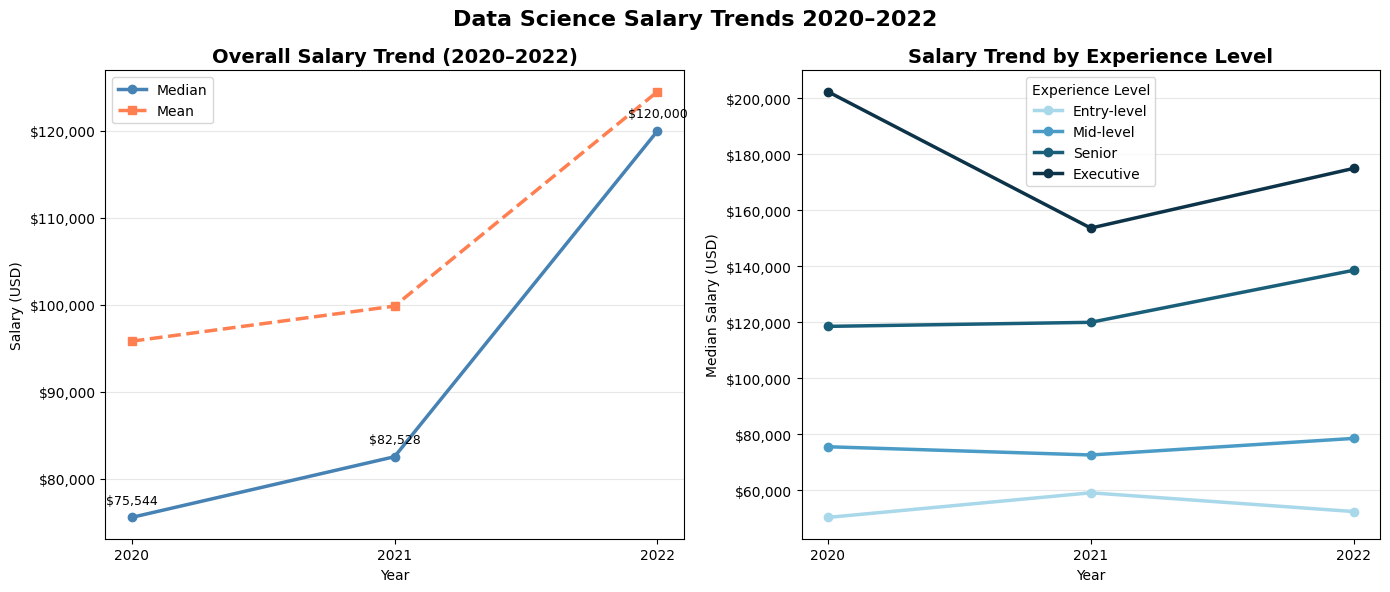

Median salary by year:
work_year
2020     $75,544
2021     $82,528
2022    $120,000
Name: salary_in_usd, dtype: object


In [13]:
# ------------------------------------------------------------
# Visualization 5: Salary Trends by Year and Experience Level
# Purpose: Show how data science salaries evolved 2020-2022
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Overall median salary by year
yearly = df.groupby('work_year')['salary_in_usd'].agg(['median','mean']).reset_index()

axes[0].plot(yearly['work_year'], yearly['median'], marker='o', linewidth=2.5,
             color='steelblue', label='Median')
axes[0].plot(yearly['work_year'], yearly['mean'], marker='s', linewidth=2.5,
             color='coral', linestyle='--', label='Mean')
axes[0].set_title('Overall Salary Trend (2020–2022)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Salary (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xticks([2020, 2021, 2022])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for _, row in yearly.iterrows():
    axes[0].annotate(f"${row['median']:,.0f}", (row['work_year'], row['median']),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

# Plot 2 — Salary by year and experience level
exp_order = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
colors = ['#a8d8ea', '#4a9cc7', '#1a5f7a', '#0d3349']

for exp, color in zip(exp_order, colors):
    data = df[df['experience_level'] == exp].groupby('work_year')['salary_in_usd'].median().reset_index()
    axes[1].plot(data['work_year'], data['salary_in_usd'], marker='o',
                 linewidth=2.5, label=exp, color=color)

axes[1].set_title('Salary Trend by Experience Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Salary (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xticks([2020, 2021, 2022])
axes[1].legend(title='Experience Level')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Data Science Salary Trends 2020–2022', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/05_salary_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Median salary by year:")
print(df.groupby('work_year')['salary_in_usd'].median().apply(lambda x: f'${x:,.0f}'))

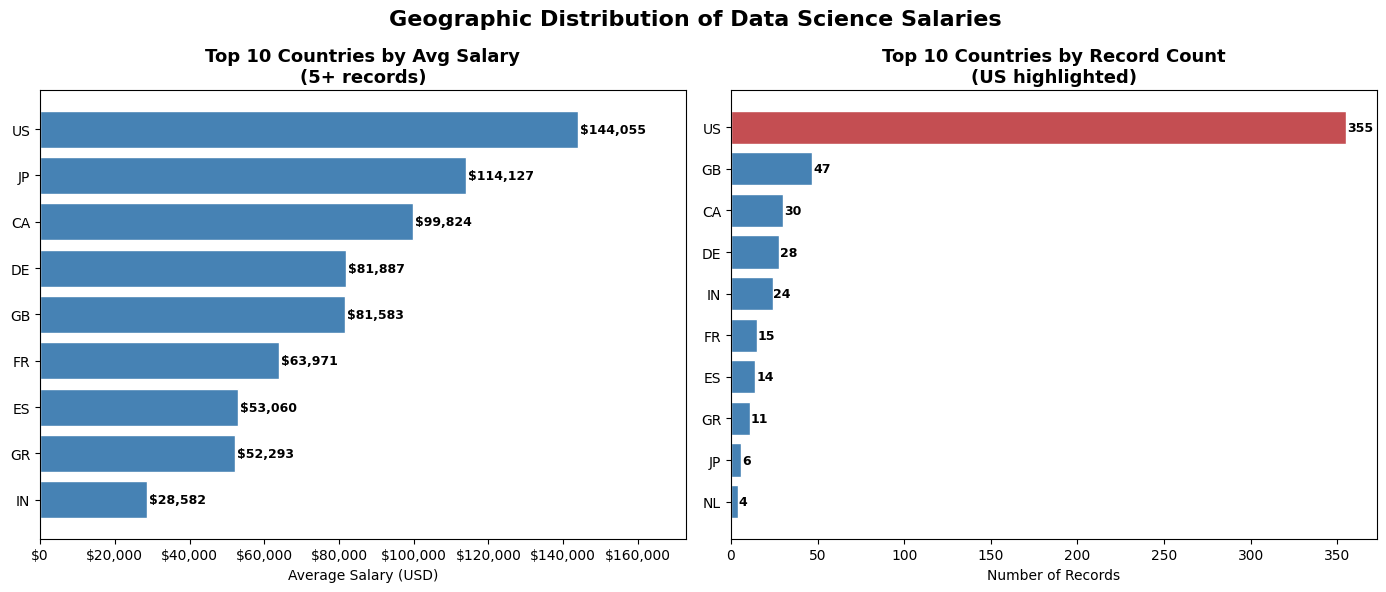

Top 10 countries by record count:
company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
Name: count, dtype: int64


In [14]:
# ------------------------------------------------------------
# Visualization 6: Top 10 Countries by Average Salary
# Purpose: Show geographic salary differences
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Top 10 company locations by avg salary (min 5 records)
country_counts = df['company_location'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

top10_countries = (df[df['company_location'].isin(valid_countries)]
                   .groupby('company_location')['salary_in_usd']
                   .mean()
                   .sort_values(ascending=True)
                   .tail(10))

bars = axes[0].barh(top10_countries.index, top10_countries.values,
                     color='steelblue', edgecolor='white')
for bar, val in zip(bars, top10_countries.values):
    axes[0].text(val + 500, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

axes[0].set_title('Top 10 Countries by Avg Salary\n(5+ records)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Salary (USD)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xlim(0, top10_countries.max() * 1.2)

# Plot 2 — Record count by top 10 countries
top10_volume = country_counts.head(10).sort_values(ascending=True)
colors = ['#c44e52' if c == 'US' else 'steelblue' for c in top10_volume.index]
bars2 = axes[1].barh(top10_volume.index, top10_volume.values,
                      color=colors, edgecolor='white')
for bar, val in zip(bars2, top10_volume.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9, fontweight='bold')

axes[1].set_title('Top 10 Countries by Record Count\n(US highlighted)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Records')

plt.suptitle('Geographic Distribution of Data Science Salaries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/06_geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 countries by record count:")
print(country_counts.head(10))

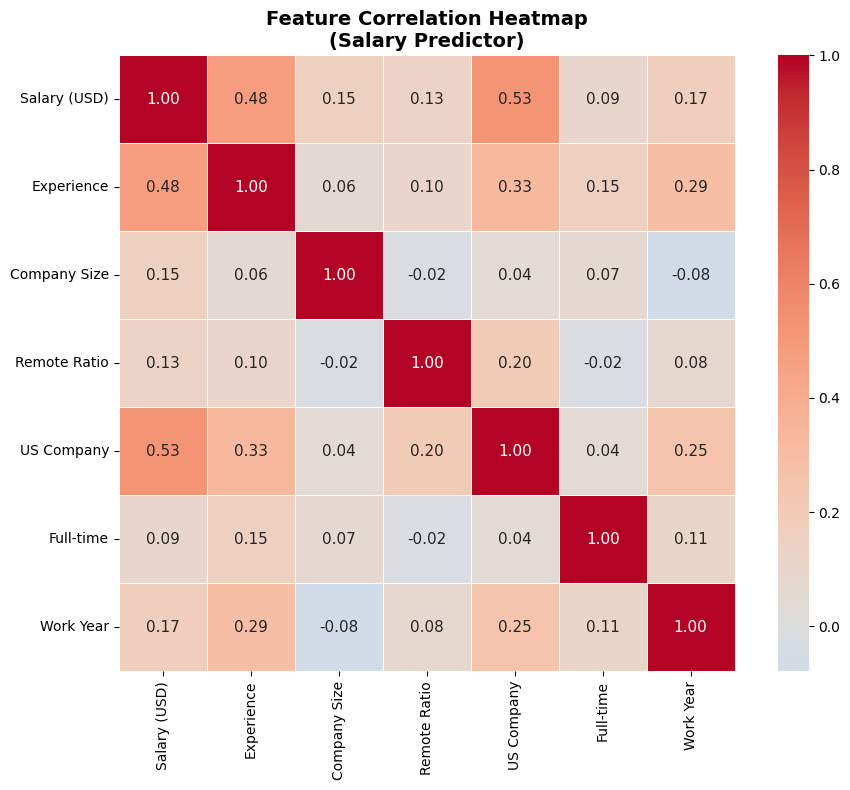

Correlation with Salary (USD):
US Company      0.532
Experience      0.484
Work Year       0.170
Company Size    0.151
Remote Ratio    0.132
Full-time       0.092
Name: Salary (USD), dtype: object


In [21]:
# ------------------------------------------------------------
# Visualization 7: Feature Correlation Heatmap
# Purpose: Understand relationships between numeric variables
# and encoded categorical features before modeling
# ------------------------------------------------------------

# Encode categoricals numerically for correlation analysis
df_encoded = df.copy()

exp_order_map = {'Entry-level': 1, 'Mid-level': 2, 'Senior': 3, 'Executive': 4}
size_order_map = {'Small': 1, 'Medium': 2, 'Large': 3}

df_encoded['experience_encoded'] = df_encoded['experience_level'].map(exp_order_map)
df_encoded['company_size_encoded'] = df_encoded['company_size'].map(size_order_map)
df_encoded['is_us_company'] = (df_encoded['company_location'] == 'US').astype(int)
df_encoded['is_fulltime'] = (df_encoded['employment_type'] == 'Full-time').astype(int)

# Select numeric columns for correlation
corr_cols = ['salary_in_usd', 'experience_encoded', 'company_size_encoded',
             'remote_ratio', 'is_us_company', 'is_fulltime', 'work_year']

corr_matrix = df_encoded[corr_cols].corr()

# Rename for readability
corr_matrix.columns = ['Salary (USD)', 'Experience', 'Company Size',
                        'Remote Ratio', 'US Company', 'Full-time', 'Work Year']
corr_matrix.index = corr_matrix.columns

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 11})

ax.set_title('Feature Correlation Heatmap\n(Salary Predictor)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with Salary (USD):")
print(corr_matrix['Salary (USD)'].drop('Salary (USD)').sort_values(ascending=False).apply(lambda x: f'{x:.3f}'))

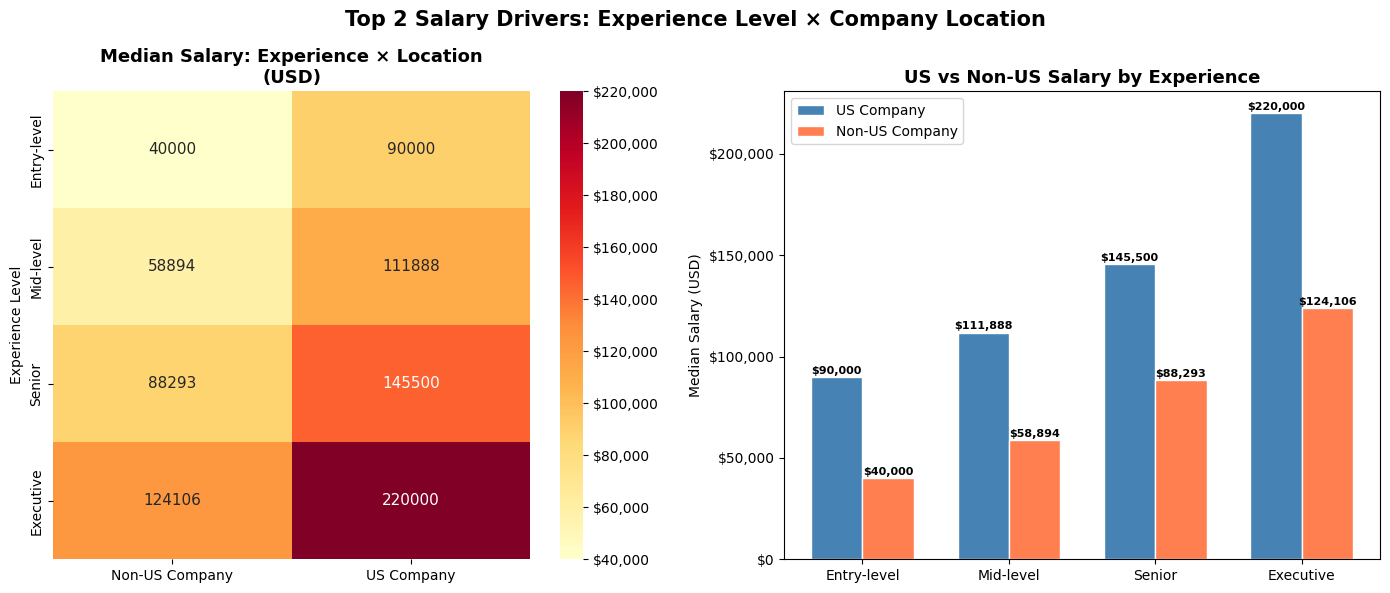

In [22]:
# ------------------------------------------------------------
# Visualization 8: Salary Heatmap — Experience vs US Company
# Purpose: Show the interaction between top 2 salary drivers
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Heatmap of median salary by experience x company location (US vs non-US)
df_encoded['company_region'] = df_encoded['is_us_company'].map({1: 'US Company', 0: 'Non-US Company'})
exp_order = ['Entry-level', 'Mid-level', 'Senior', 'Executive']

pivot = df.copy()
pivot['company_region'] = (df['company_location'] == 'US').map({True: 'US Company', False: 'Non-US Company'})
heatmap_data = pivot.groupby(['experience_level', 'company_region'])['salary_in_usd'].median().unstack()
heatmap_data = heatmap_data.reindex(exp_order)

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[0], annot_kws={'size': 11},
            cbar_kws={'format': '${x:,.0f}'})
axes[0].set_title('Median Salary: Experience × Location\n(USD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Experience Level')

# Plot 2 — Grouped bar chart of the same data
x = np.arange(len(exp_order))
width = 0.35

us_vals = [heatmap_data.loc[e, 'US Company'] if 'US Company' in heatmap_data.columns else 0 for e in exp_order]
nonus_vals = [heatmap_data.loc[e, 'Non-US Company'] if 'Non-US Company' in heatmap_data.columns else 0 for e in exp_order]

bars1 = axes[1].bar(x - width/2, us_vals, width, label='US Company', color='steelblue', edgecolor='white')
bars2 = axes[1].bar(x + width/2, nonus_vals, width, label='Non-US Company', color='coral', edgecolor='white')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=8, fontweight='bold')

axes[1].set_title('US vs Non-US Salary by Experience', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(exp_order)
axes[1].set_ylabel('Median Salary (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

plt.suptitle('Top 2 Salary Drivers: Experience Level × Company Location',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/08_experience_location_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ------------------------------------------------------------
# Feature Engineering
# Goal: Transform raw columns into ML-ready features
# Decisions:
# 1. Log-transform salary (fixes skew, improves model accuracy)
# 2. Ordinal encode experience level (natural order exists)
# 3. Flag US company (strongest single predictor)
# 4. Group rare job titles into 'Other' (50 titles, many with 1-2 records)
# 5. Drop employee_residence (redundant with company_location)
# ------------------------------------------------------------

df_ml = df.copy()

# 1. Log-transform the target variable
df_ml['log_salary'] = np.log1p(df_ml['salary_in_usd'])

# 2. Ordinal encode experience level
exp_map = {'Entry-level': 1, 'Mid-level': 2, 'Senior': 3, 'Executive': 4}
df_ml['experience_encoded'] = df_ml['experience_level'].map(exp_map)

# 3. Flag US company
df_ml['is_us_company'] = (df_ml['company_location'] == 'US').astype(int)

# 4. Group rare job titles — keep top 10, label rest as 'Other'
top_titles = df_ml['job_title'].value_counts().head(10).index
df_ml['job_title_grouped'] = df_ml['job_title'].apply(
    lambda x: x if x in top_titles else 'Other'
)

# 5. Ordinal encode company size
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
df_ml['company_size_encoded'] = df_ml['company_size'].map(size_map)

# 6. Flag full-time employment
df_ml['is_fulltime'] = (df_ml['employment_type'] == 'Full-time').astype(int)

# Verify
print("New features created:")
print(df_ml[['experience_encoded', 'is_us_company', 'job_title_grouped',
             'company_size_encoded', 'is_fulltime', 'log_salary']].head(8))

print(f"\nJob title groups: {df_ml['job_title_grouped'].nunique()}")
print(df_ml['job_title_grouped'].value_counts())

New features created:
   experience_encoded  is_us_company           job_title_grouped  \
0                   2              0              Data Scientist   
1                   3              0  Machine Learning Scientist   
2                   3              0           Big Data Engineer   
3                   2              0                       Other   
4                   3              1   Machine Learning Engineer   
5                   1              1                Data Analyst   
6                   3              1                       Other   
7                   2              0              Data Scientist   

   company_size_encoded  is_fulltime  log_salary  
0                     3            1       11.29  
1                     1            1       12.47  
2                     2            1       11.60  
3                     1            1        9.90  
4                     3            1       11.92  
5                     3            1       11.18  
6       

In [24]:
# ------------------------------------------------------------
# ML Model — Random Forest Regressor
# Target: log_salary (log-transformed for better predictions)
# Why Random Forest:
# - Handles mixed feature types well
# - Robust to outliers
# - Provides feature importance
# - No need to scale features
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# --- Define features ---
features = [
    'experience_encoded',
    'is_us_company',
    'company_size_encoded',
    'remote_ratio',
    'is_fulltime',
    'work_year',
    'job_title_grouped'
]

# One-hot encode job_title_grouped (nominal, no natural order)
df_model = pd.get_dummies(df_ml[features], columns=['job_title_grouped'])

X = df_model
y = df_ml['log_salary']

# --- Train/test split: 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

# --- Train model ---
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# --- Predict and evaluate ---
y_pred_log = rf_model.predict(X_test)

# Convert back from log to actual USD for interpretable metrics
y_pred_usd = np.expm1(y_pred_log)
y_test_usd = np.expm1(y_test)

r2  = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_test_usd, y_pred_usd)

print(f"\n=== MODEL PERFORMANCE ===")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : ${mae:,.0f}")
print(f"\nInterpretation:")
print(f"  The model explains {r2*100:.1f}% of salary variance")
print(f"  Average prediction error: ${mae:,.0f}")

Training samples: 485
Testing samples:  122
Features:         17

=== MODEL PERFORMANCE ===
R² Score : 0.4539
MAE      : $34,225

Interpretation:
  The model explains 45.4% of salary variance
  Average prediction error: $34,225


In [25]:
# ------------------------------------------------------------
# Model Improvement
# Changes:
# 1. Add is_us_resident feature (employee lives in US)
# 2. Try Gradient Boosting — generally stronger on tabular data
# 3. Compare both models fairly on same train/test split
# ------------------------------------------------------------

from sklearn.ensemble import GradientBoostingRegressor

# Add missing feature — employee residence in US
df_ml['is_us_resident'] = (df_ml['employee_residence'] == 'US').astype(int)

# Rebuild feature set with new feature
features_v2 = [
    'experience_encoded',
    'is_us_company',
    'is_us_resident',
    'company_size_encoded',
    'remote_ratio',
    'is_fulltime',
    'work_year',
    'job_title_grouped'
]

df_model_v2 = pd.get_dummies(df_ml[features_v2], columns=['job_title_grouped'])

X2 = df_model_v2
y2 = df_ml['log_salary']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# --- Model 1: Random Forest (improved features) ---
rf_v2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_v2.fit(X_train2, y_train2)
rf_pred = np.expm1(rf_v2.predict(X_test2))
rf_actual = np.expm1(y_test2)
rf_r2  = r2_score(y_test2, rf_v2.predict(X_test2))
rf_mae = mean_absolute_error(rf_actual, rf_pred)

# --- Model 2: Gradient Boosting ---
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=4, random_state=42)
gb_model.fit(X_train2, y_train2)
gb_pred = np.expm1(gb_model.predict(X_test2))
gb_r2  = r2_score(y_test2, gb_model.predict(X_test2))
gb_mae = mean_absolute_error(rf_actual, gb_pred)

print("=== MODEL COMPARISON ===")
print(f"{'Model':<30} {'R²':>8} {'MAE':>12}")
print("-" * 52)
print(f"{'Random Forest v1 (baseline)':<30} {'0.4539':>8} {'$34,225':>12}")
print(f"{'Random Forest v2 (+residence)':<30} {rf_r2:>8.4f} {'${:,.0f}'.format(rf_mae):>12}")
print(f"{'Gradient Boosting':<30} {gb_r2:>8.4f} {'${:,.0f}'.format(gb_mae):>12}")

=== MODEL COMPARISON ===
Model                                R²          MAE
----------------------------------------------------
Random Forest v1 (baseline)      0.4539      $34,225
Random Forest v2 (+residence)    0.5482      $29,360
Gradient Boosting                0.5022      $30,019


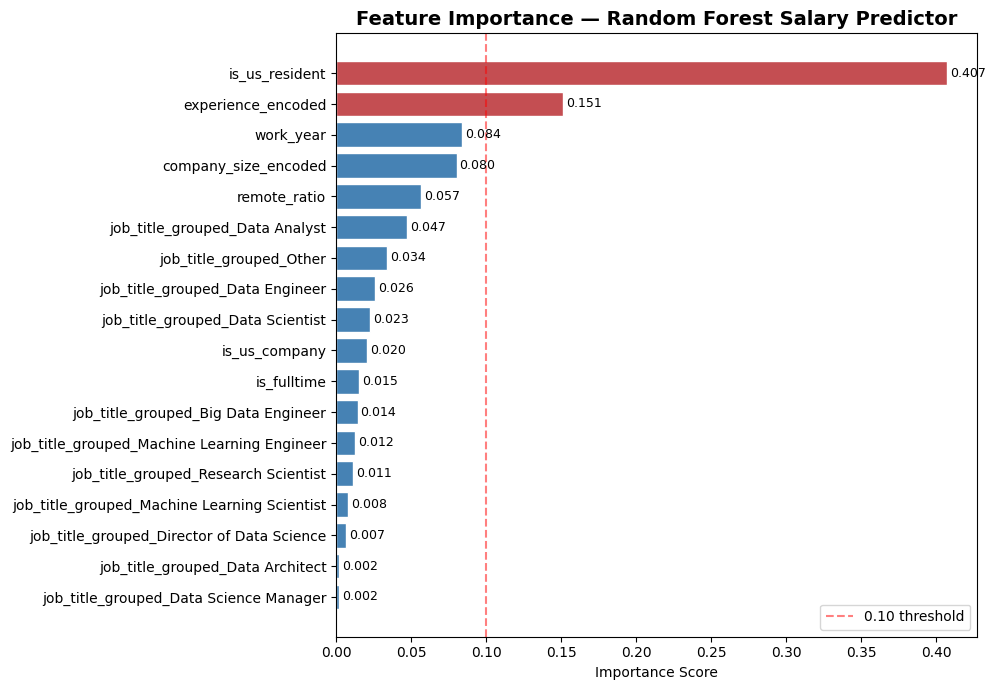

Top features:
is_us_resident                     0.4070
experience_encoded                 0.1512
work_year                          0.0837
company_size_encoded               0.0802
remote_ratio                       0.0568
job_title_grouped_Data Analyst     0.0471
job_title_grouped_Other            0.0340
job_title_grouped_Data Engineer    0.0258
dtype: object


In [26]:
# ------------------------------------------------------------
# Visualization 9: Feature Importance
# Purpose: Show which features drive predictions most
# ------------------------------------------------------------

feature_names = df_model_v2.columns.tolist()
importances = rf_v2.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c44e52' if v > 0.1 else 'steelblue' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importance — Random Forest Salary Predictor',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='0.10 threshold')
ax.legend()

plt.tight_layout()
plt.savefig('../visuals/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top features:")
print(feat_imp.sort_values(ascending=False).head(8).apply(lambda x: f'{x:.4f}'))

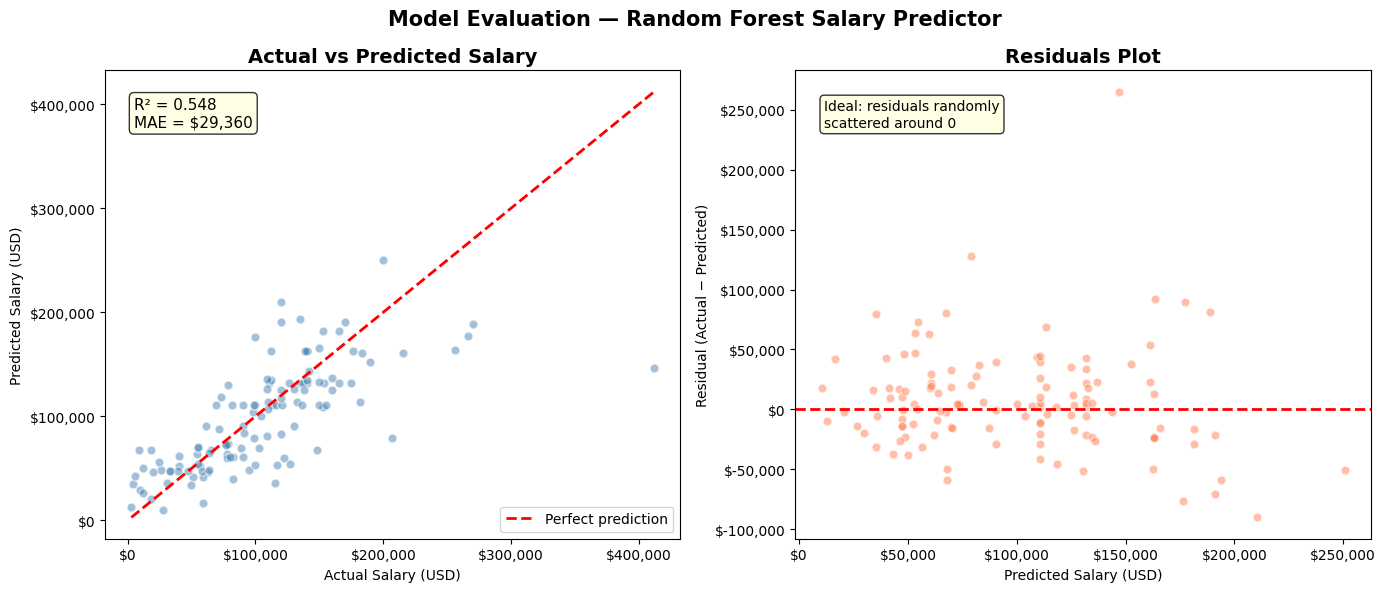

=== PREDICTION ERROR BREAKDOWN ===
Within $20K : 59 / 122 = 48.4%
Within $40K : 92 / 122 = 75.4%
Within $60K : 108 / 122 = 88.5%
Over  $60K  : 14 / 122 = 11.5%


In [27]:
# ------------------------------------------------------------
# Visualization 10: Actual vs Predicted Salary
# Purpose: Visually validate model performance on test set
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Actual vs Predicted scatter
axes[0].scatter(rf_actual, rf_pred, alpha=0.5, color='steelblue', edgecolor='white', s=40)
min_val = min(rf_actual.min(), rf_pred.min())
max_val = max(rf_actual.max(), rf_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Salary', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()
axes[0].annotate(f'R² = {rf_r2:.3f}\nMAE = ${rf_mae:,.0f}',
                 xy=(0.05, 0.88), xycoords='axes fraction',
                 fontsize=11, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Plot 2 — Residuals plot
residuals = rf_actual.values - rf_pred
axes[1].scatter(rf_pred, residuals, alpha=0.5, color='coral', edgecolor='white', s=40)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Salary (USD)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].annotate('Ideal: residuals randomly\nscattered around 0',
                 xy=(0.05, 0.88), xycoords='axes fraction',
                 fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Model Evaluation — Random Forest Salary Predictor', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/10_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed error breakdown
errors = np.abs(rf_actual.values - rf_pred)
print("=== PREDICTION ERROR BREAKDOWN ===")
print(f"Within $20K : {(errors < 20000).sum()} / {len(errors)} = {(errors < 20000).mean()*100:.1f}%")
print(f"Within $40K : {(errors < 40000).sum()} / {len(errors)} = {(errors < 40000).mean()*100:.1f}%")
print(f"Within $60K : {(errors < 60000).sum()} / {len(errors)} = {(errors < 60000).mean()*100:.1f}%")
print(f"Over  $60K  : {(errors >= 60000).sum()} / {len(errors)} = {(errors >= 60000).mean()*100:.1f}%")

In [28]:
# ------------------------------------------------------------
# Save the trained model and feature columns
# Both files are needed for the Streamlit app to work
# ------------------------------------------------------------

import pickle

# Save model
with open('../models/salary_model.pkl', 'wb') as f:
    pickle.dump(rf_v2, f)

# Save feature column names (needed to align inputs in Streamlit)
with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(df_model_v2.columns.tolist(), f)

print("✅ Model saved to models/salary_model.pkl")
print("✅ Feature columns saved to models/feature_columns.pkl")
print(f"\nFeature columns ({len(df_model_v2.columns)}):")
print(df_model_v2.columns.tolist())

✅ Model saved to models/salary_model.pkl
✅ Feature columns saved to models/feature_columns.pkl

Feature columns (18):
['experience_encoded', 'is_us_company', 'is_us_resident', 'company_size_encoded', 'remote_ratio', 'is_fulltime', 'work_year', 'job_title_grouped_Big Data Engineer', 'job_title_grouped_Data Analyst', 'job_title_grouped_Data Architect', 'job_title_grouped_Data Engineer', 'job_title_grouped_Data Science Manager', 'job_title_grouped_Data Scientist', 'job_title_grouped_Director of Data Science', 'job_title_grouped_Machine Learning Engineer', 'job_title_grouped_Machine Learning Scientist', 'job_title_grouped_Other', 'job_title_grouped_Research Scientist']
